In [1]:
#Author: Yiying Jiao

In [2]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Load prepared dataset
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/21_260311_features_for_training_df.csv")

In [4]:
print(df)

           Close       pos      neut       neg  sentiment_score  \
0     126.239700  0.984030  0.001089  0.014881         0.969149   
1     127.800476  0.953821  0.045860  0.000318         0.953503   
2     123.498535  0.896802  0.025534  0.077664         0.819138   
3     127.712692  0.830714  0.095507  0.073780         0.756934   
4     128.815018  0.891560  0.047626  0.060814         0.830746   
...          ...       ...       ...       ...              ...   
1286  262.519989  0.867927  0.088043  0.044030         0.823897   
1287  260.290009  0.846903  0.105335  0.047762         0.799141   
1288  257.459991  0.813300  0.086471  0.100229         0.713071   
1289  259.880005  0.991167  0.002044  0.006789         0.984378   
1290  260.829987  0.876588  0.047939  0.075473         0.801115   

      rolling_sentiment  sentiment_volatility  price_change  volatility  \
0                   NaN                   NaN           NaN         NaN   
1                   NaN                   NaN

In [5]:

# Drop NaNs (from rolling/lag features)
df.dropna(inplace=True)


# Select features & target
features = ['Close','pos', 'neut', 'neg', 'sentiment_score','rolling_sentiment',
       'sentiment_volatility', 'price_change', 'volatility', 'momentum', 'rsi',
       'macd', 'ema', 'sentiment_lag_1', 'price_lag_1', 'sentiment_lag_2',
       'price_lag_2', 'sentiment_lag_3', 'price_lag_3', 'sentiment_lag_4',
       'price_lag_4', 'sentiment_lag_5', 'price_lag_5']
target = "next_close"  # we are predicting next day's price

X = df[features].values
y = df[target].values


In [6]:

timesteps = 1

#slipt first
split_index = int(0.85 * len(df))
X_train_raw, X_test_raw = X[:split_index], X[split_index:]
y_train_raw, y_test_raw = y[:split_index], y[split_index:]

#fit scaler only on training data
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)
X_test  = scaler_X.transform(X_test_raw)

scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1))
y_test  = scaler_y.transform(y_test_raw.reshape(-1, 1))   # transform, don't fit

X_train_seq, X_test_seq = X_train, X_test
y_train_seq, y_test_seq = y_train, y_test

# Reshape X for LSTM (samples, timesteps, features)
num_samples_test = X_test_seq.shape[0] // timesteps * timesteps
num_samples_train = X_train_seq.shape[0] // timesteps * timesteps
X_test_seq = X_test_seq[:num_samples_test]
X_test_seq = X_test_seq.reshape((num_samples_test // timesteps, timesteps, X_test_seq.shape[1]))
X_train_seq = X_train_seq[:num_samples_train]
X_train_seq = X_train_seq.reshape((num_samples_train // timesteps, timesteps, X_train_seq.shape[1]))


y_train_seq = y_train_seq[:num_samples_train]  # Trim y to match X
y_train_seq = y_train_seq.reshape(-1, timesteps)[:, -1]  # Keep only last value
y_train_seq = y_train_seq.reshape(-1, 1)  # Ensure correct shape

y_test_seq = y_test_seq[:num_samples_test]  # Trim y to match X
y_test_seq = y_test_seq.reshape(-1, timesteps)[:, -1]  # Keep only last value
y_test_seq = y_test_seq.reshape(-1, 1)  # Ensure correct shape

In [7]:
print("X_train_seq shape:", X_train_seq.shape)  # Should be (samples, timesteps, features)
print("y_train_seq shape:", y_train_seq.shape)  # Should be (samples, 1)

X_train_seq shape: (1008, 1, 23)
y_train_seq shape: (1008, 1)


In [8]:
# Define LSTM Model

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),  # Last LSTM layer without return sequences
    Dropout(0.2),
    Dense(25, activation="tanh"), #switched from relu to tanh but not sure about which to use
    Dense(1, activation="linear")  # Output one value (next day return)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        14,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,301 (141.80 KB)

 Trainable params: 36,301 (141.80 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train model
history = model.fit(X_train_seq, y_train_seq, epochs=55, batch_size=16, validation_data=(X_test_seq, y_test_seq), verbose=1)


Epoch 1/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0540 - mae: 0.1765 - val_loss: 0.0324 - val_mae: 0.1658
Epoch 2/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - mae: 0.0595 - val_loss: 0.0045 - val_mae: 0.0477
Epoch 3/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0045 - mae: 0.0505 - val_loss: 0.0042 - val_mae: 0.0489
Epoch 4/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - mae: 0.0455 - val_loss: 0.0039 - val_mae: 0.0529
Epoch 5/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - mae: 0.0449 - val_loss: 0.0063 - val_mae: 0.0679
Epoch 6/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0425 - val_loss: 0.0018 - val_mae: 0.0304
Epoch 7/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - mae: 0.0390 - val_loss: 0.0044 - val_mae: 0.0556
Epoch 8/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - mae: 0.0370 - val_loss: 0.0036 - val_mae: 0.0494
Epoch 9/55
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - mae: 

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Evaluate model
train_loss = model.evaluate(X_train_seq, y_train_seq)
test_loss = model.evaluate(X_test_seq, y_test_seq)
print(f"Scaled Train Loss mse, mae: {train_loss}, Scaled Test Loss mse, Test mae: {test_loss}")

# Make predictions
y_pred_scaled = model.predict(X_test_seq)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4198e-04 - mae: 0.0187 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - mae: 0.0385 
Scaled Train Loss mse, mae: [0.0006419831188395619, 0.018745947629213333], Scaled Test Loss mse, Test mae: [0.0020088942255824804, 0.038533516228199005]
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [11]:
# check if y values are scaled
print("y_test_seq min/max:", y_test_seq.min(), y_test_seq.max())

# Convert predictions back to original price scale
y_pred_original = scaler_y.inverse_transform(y_pred_scaled)

# Convert y_test back to original scale for comparison
y_test_original = scaler_y.inverse_transform(y_test_seq)

# Compute R²
#R2=1−(SSres/​SStot​​)

mae_real = mean_absolute_error(y_test_original, y_pred_original)
rmse_real = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)
print(f"Test real MAE ($): {mae_real:.4f}, Test real RMSE ($): {rmse_real:.4f}")

print(f"R² Score: {r2:.4f}")



y_test_seq min/max: 0.5687900823853023 1.1902033863421078
Test real MAE ($): 5.5765, Test real RMSE ($): 6.4863
R² Score: 0.9281


In [16]:
# comparison to a native baseline where we guesse every next's day's price the same as today's

baseline_pred = df["Close"].values[split_index:]
actual_next   = df["next_close"].values[split_index:]

base_mae  = mean_absolute_error(actual_next, baseline_pred)
base_rmse = np.sqrt(mean_squared_error(actual_next, baseline_pred))
base_r2   = r2_score(actual_next, baseline_pred)

print("native baseline")
print(f"MAE : {base_mae:.4f}   RMSE: {base_rmse:.4f}   R2: {base_r2:.4f}")
print("my model")
print(f"MAE : {mae_real:.4f}   RMSE: {rmse_real:.4f}   R2: {r2:.4f}")

native baseline
MAE : 2.4552   RMSE: 3.5276   R2: 0.9787
my model
MAE : 5.5765   RMSE: 6.4863   R2: 0.9281


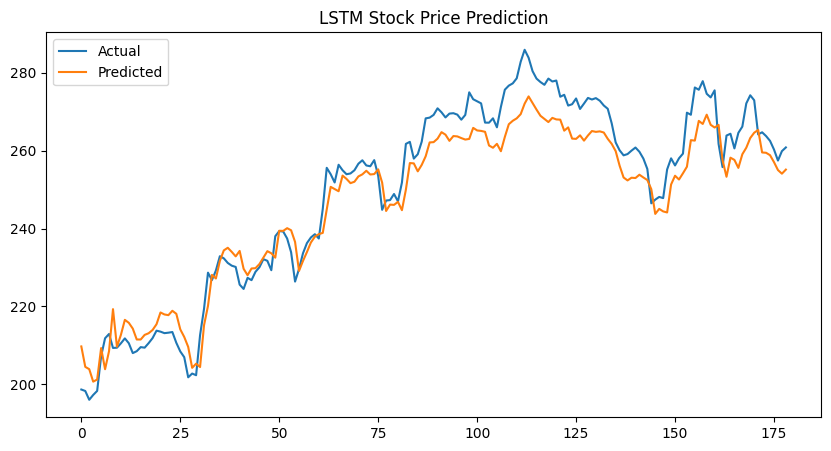

In [13]:

# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test_original, label="Actual")
plt.plot(y_pred_original, label="Predicted")
plt.legend()
plt.title("LSTM Stock Price Prediction")
plt.show()
